In [1]:
import urllib.request
import pandas as pd

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
urllib.request.urlretrieve(url, "heart.csv")

# Check karo
df = pd.read_csv("heart.csv")
print("Dataset downloaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset downloaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
!pip install scikit-learn matplotlib seaborn pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
print("Columns:", df.columns.tolist())
print()
df.info()

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
print("Missing Values:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


Target Value Counts:
target
1    165
0    138
Name: count, dtype: int64

0 = No Heart Disease
1 = Heart Disease


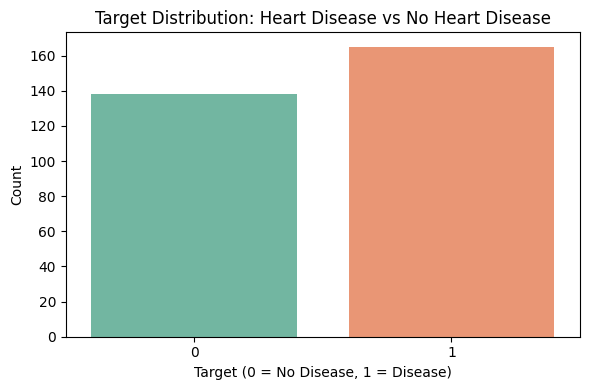

In [7]:
print("Target Value Counts:")
print(df['target'].value_counts())
print()
print("0 = No Heart Disease")
print("1 = Heart Disease")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title('Target Distribution: Heart Disease vs No Heart Disease')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

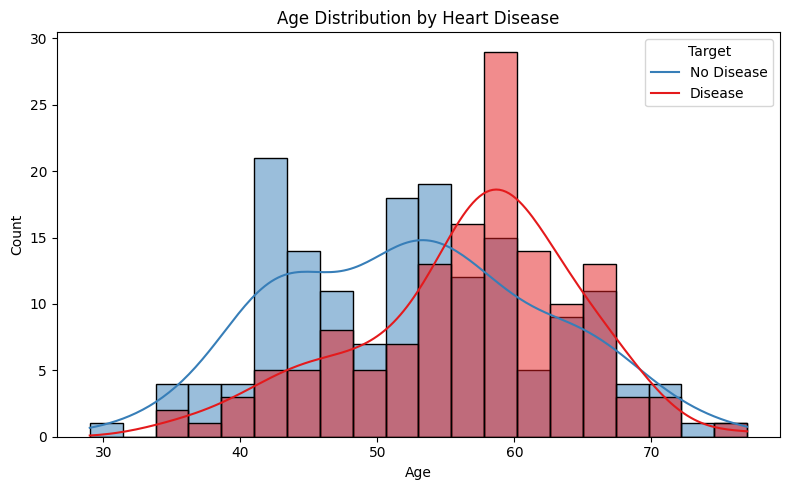

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set1', bins=20)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

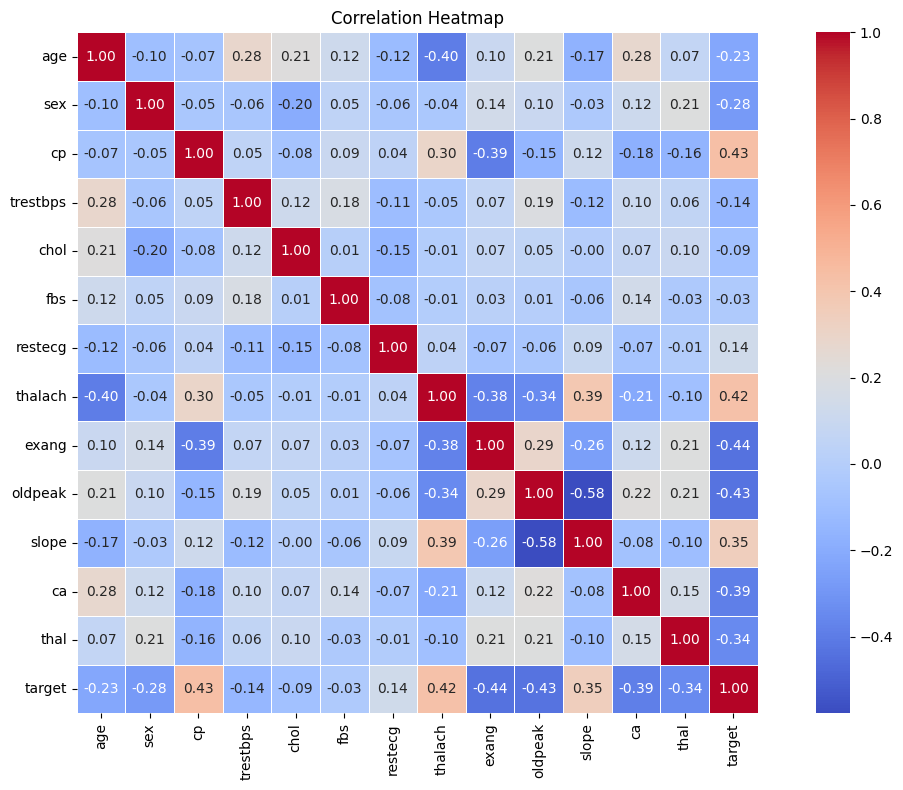

In [10]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

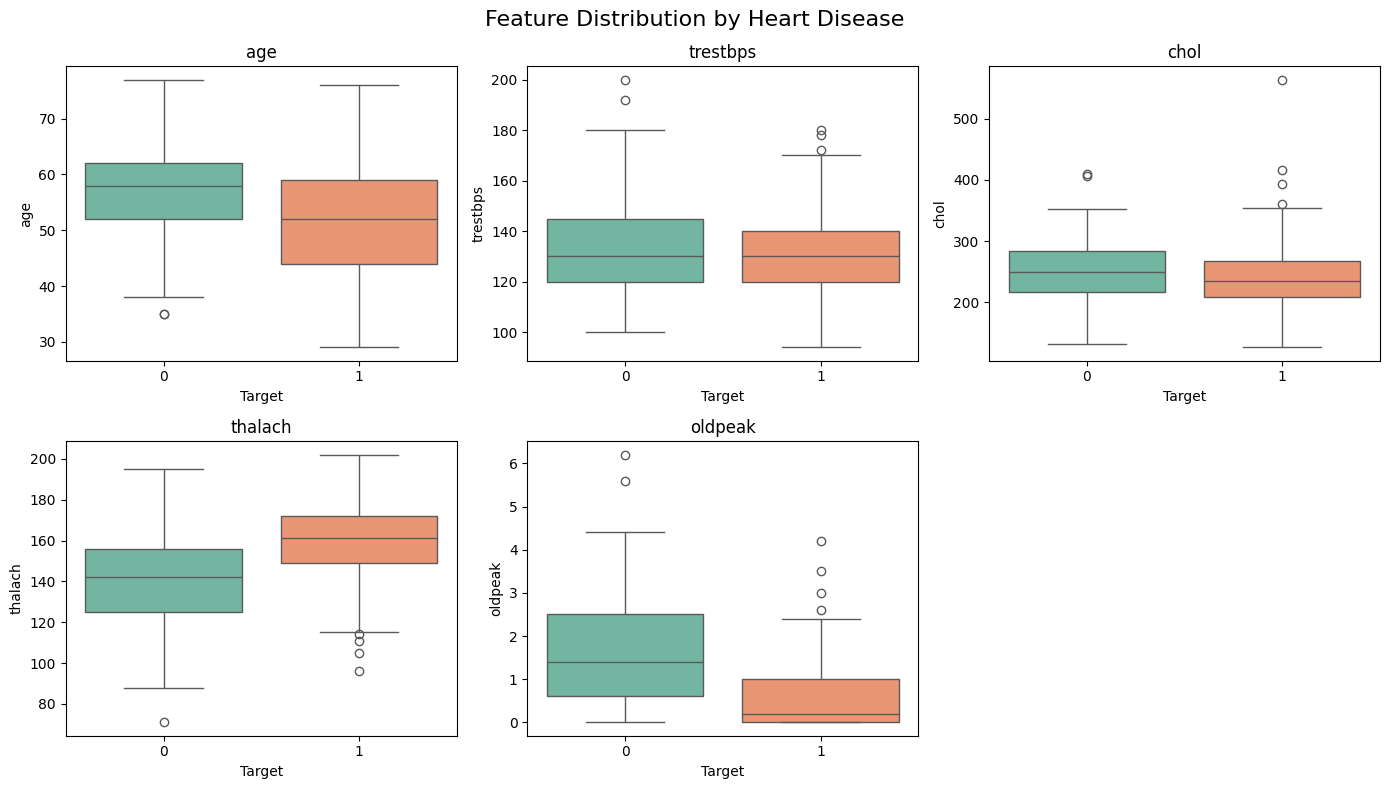

In [11]:
features_to_plot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distribution by Heart Disease', fontsize=16)

for i, feature in enumerate(features_to_plot):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df, x='target', y=feature,
                hue='target', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature}')
    ax.set_xlabel('Target')

# Last empty subplot hide karo
axes[1][2].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [15]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc * 100, 2), "%")

Logistic Regression Accuracy: 85.25 %


In [16]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_acc * 100, 2), "%")

Decision Tree Accuracy: 81.97 %


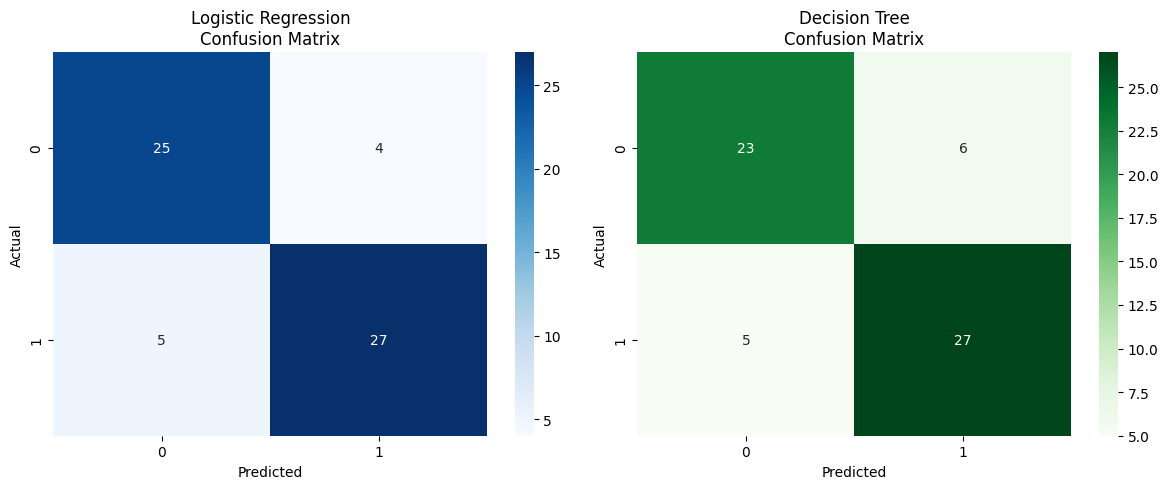

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [18]:
print("=" * 45)
print("LOGISTIC REGRESSION Classification Report")
print("=" * 45)
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Disease']))

print("=" * 45)
print("DECISION TREE Classification Report")
print("=" * 45)
print(classification_report(y_test, dt_pred,
      target_names=['No Disease', 'Disease']))

LOGISTIC REGRESSION Classification Report
              precision    recall  f1-score   support

  No Disease       0.83      0.86      0.85        29
     Disease       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

DECISION TREE Classification Report
              precision    recall  f1-score   support

  No Disease       0.82      0.79      0.81        29
     Disease       0.82      0.84      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



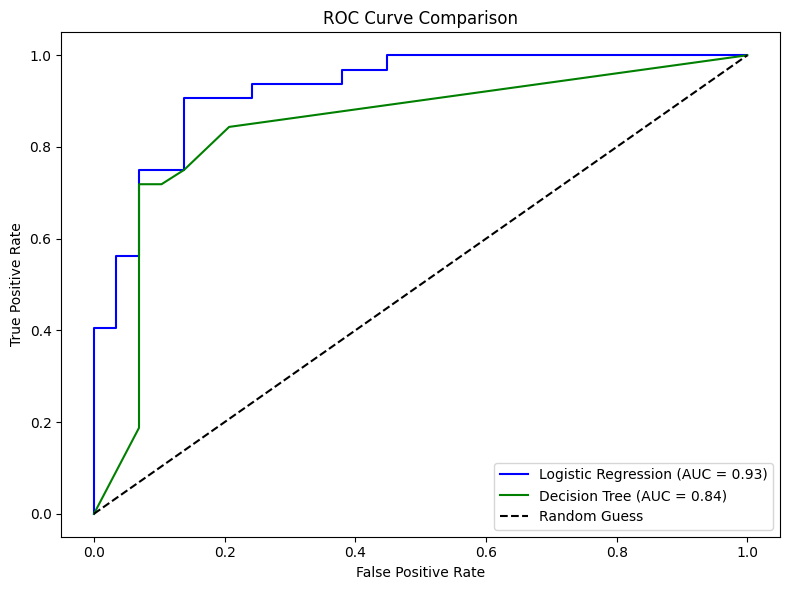

In [19]:
# Probabilities
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt_model.predict_proba(X_test)[:, 1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='blue')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

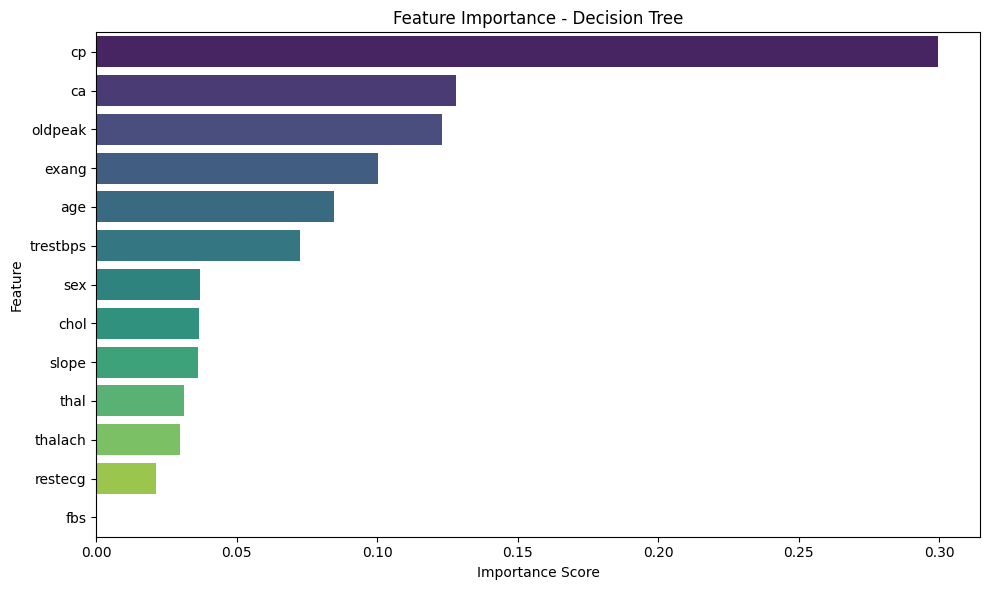

In [20]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [21]:
print("=" * 50)
print("FINAL SUMMARY — Heart Disease Prediction")
print("=" * 50)
print(f"\nLogistic Regression:")
print(f"  Accuracy : {lr_acc * 100:.2f}%")
print(f"  AUC Score: {lr_auc:.4f}")

print(f"\nDecision Tree:")
print(f"  Accuracy : {dt_acc * 100:.2f}%")
print(f"  AUC Score: {dt_auc:.4f}")

print("\nTop 3 Important Features (Decision Tree):")
for i, row in feat_df.head(3).iterrows():
    print(f"  {row['Feature']} — {row['Importance']:.4f}")

print("\nConclusion:")
if lr_auc > dt_auc:
    print("  Logistic Regression performed BETTER (Higher AUC)!")
else:
    print("  Decision Tree performed BETTER (Higher AUC)!")

FINAL SUMMARY — Heart Disease Prediction

Logistic Regression:
  Accuracy : 85.25%
  AUC Score: 0.9267

Decision Tree:
  Accuracy : 81.97%
  AUC Score: 0.8427

Top 3 Important Features (Decision Tree):
  cp — 0.2996
  ca — 0.1280
  oldpeak — 0.1229

Conclusion:
  Logistic Regression performed BETTER (Higher AUC)!
